In [4]:
!pip install scipy --q

In [2]:
!pip install pycaret --q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.7/484.7 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 65.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 47.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 39.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 79.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.2 MB/s et

In [5]:
!pip install plotly

In [6]:
#from pycaret.clustering import *
import pandas as pd

from sklearn.feature_selection import VarianceThreshold
from sklearn.datasets import make_classification
import numpy as np

import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist
import lxml
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity

from scipy.spatial.distance import cdist

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Tratamento de Dados

In [ ]:
df_all_stats = pd.read_csv('/content/drive/MyDrive/df_all_stats_2023_2024.csv').drop(columns = ['Unnamed: 0'])
df_all_stats.head()

,Player,Nation,Pos,Age,MP,Playing Time Starts,Playing Time Min,Playing Time 90s,Performance Gls,Performance Ast,...,Progression PrgR,Per 90 Minutes xG,Per 90 Minutes xAG,Per 90 Minutes xG+xAG,Per 90 Minutes npxG,Per 90 Minutes npxG+xAG,Performance Recov,Aerial Duels Won,Aerial Duels Lost,Aerial Duels Won%
0,Hannes Hermes,de GER,MF,18-300,12.0,12.0,1044.0,11.6,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Finn Cramer,0,MF,0,12.0,12.0,934.0,10.4,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Janis Hagemann,de GER,DF,18-215,12.0,12.0,906.0,10.1,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Malte Zumdieck,de GER,FW,18-277,11.0,11.0,840.0,9.3,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Lasse Zumdieck,de GER,FW,18-277,11.0,10.0,868.0,9.6,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_all_stats = pd.read_csv('/content/drive/MyDrive/df_all_stats_2022_2023.csv').drop(columns = ['Unnamed: 0'])
df_all_stats.head()

,Player,Nation,Pos,Age,MP,Playing Time Starts,Playing Time Min,Playing Time 90s,Performance Gls,Performance Ast,...,Per 90 Minutes xG,Per 90 Minutes xAG,Per 90 Minutes xG+xAG,Per 90 Minutes npxG,Per 90 Minutes npxG+xAG,Performance Recov,Aerial Duels Won,Aerial Duels Lost,Aerial Duels Won%,Playing Time MP
0,Milan Mijatović,me MNE,GK,35.0,30.0,30.0,2700.0,30.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Christofer Gonzáles,pe PER,"MF,FW",29.0,26.0,25.0,2207.0,24.5,4.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Reinaldo Lenis,co COL,"FW,MF",30.0,23.0,23.0,2015.0,22.4,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Ali Ayesh Al-Salem,sa KSA,DF,0,21.0,20.0,1778.0,19.8,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Mohammed Al Oufi,sa KSA,"DF,MF",19.0,24.0,20.0,1688.0,18.8,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_all_stats['Position_2'] = df_all_stats['Pos'].str[3:]
df_all_stats['Position'] = df_all_stats['Pos'].str[:2]

df_all_stats['Position'] = df_all_stats['Position'].replace({'MF': 'Midfielder', 'DF': 'Defender', 'FW': 'Forward', 'GK': 'Goalkeeper'})
df_all_stats['Position_2'] = df_all_stats['Position_2'].replace({'MF': 'Midfielder', 'DF': 'Defender',
                                                 'FW': 'Forward', 'GK': 'Goalkeeper'})

In [ ]:
df_all_stats['Age'] = [age.split('-')[0] if '-' in age else age for age in df_all_stats['Age']]
df_all_stats['Age'] = [age.split('.')[0] if '.' in age else age for age in df_all_stats['Age']]
df_all_stats['Age'] = df_all_stats['Age'].astype('int')

In [ ]:
df_all_stats.head()

,Player,Nation,Pos,Age,MP,Playing Time Starts,Playing Time Min,Playing Time 90s,Performance Gls,Performance Ast,...,Per 90 Minutes xG+xAG,Per 90 Minutes npxG,Per 90 Minutes npxG+xAG,Performance Recov,Aerial Duels Won,Aerial Duels Lost,Aerial Duels Won%,Playing Time MP,Position_2,Position
0,Milan Mijatović,me MNE,GK,35,30.0,30.0,2700.0,30.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,Goalkeeper
1,Christofer Gonzáles,pe PER,"MF,FW",29,26.0,25.0,2207.0,24.5,4.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Forward,Midfielder
2,Reinaldo Lenis,co COL,"FW,MF",30,23.0,23.0,2015.0,22.4,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,Forward
3,Ali Ayesh Al-Salem,sa KSA,DF,0,21.0,20.0,1778.0,19.8,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,Defender
4,Mohammed Al Oufi,sa KSA,"DF,MF",19,24.0,20.0,1688.0,18.8,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Midfielder,Defender


In [ ]:
df_all_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36858 entries, 0 to 36857
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Player                   36858 non-null  object 
 1   Nation                   36858 non-null  object 
 2   Pos                      36858 non-null  object 
 3   Age                      36858 non-null  int64  
 4   MP                       36858 non-null  float64
 5   Playing Time Starts      36858 non-null  float64
 6   Playing Time Min         36858 non-null  float64
 7   Playing Time 90s         36858 non-null  float64
 8   Performance Gls          36858 non-null  float64
 9   Performance Ast          36858 non-null  float64
 10  Performance G+A          36858 non-null  float64
 11  Performance G-PK         36858 non-null  float64
 12  Performance PK           36858 non-null  float64
 13  Performance PKatt        36858 non-null  float64
 14  Performance CrdY      

In [ ]:
df_halland = df_all_stats[df_all_stats['Player'].str.contains('Dušan Vlahović')].reset_index().drop(columns = ['index'])

In [ ]:
df_halland

,Player,Nation,Pos,Age,MP,Playing Time Starts,Playing Time Min,Playing Time 90s,Performance Gls,Performance Ast,...,Per 90 Minutes xG+xAG,Per 90 Minutes npxG,Per 90 Minutes npxG+xAG,Performance Recov,Aerial Duels Won,Aerial Duels Lost,Aerial Duels Won%,Playing Time MP,Position_2,Position
0,Dušan Vlahović,rs SRB,FW,22,27.0,22.0,1925.0,21.4,10.0,2.0,...,0.57,0.34,0.46,55.0,36.0,56.0,39.1,0.0,,Forward


In [ ]:
yng_plyr = df_all_stats[((df_all_stats['Age'] <= 17) & (df_all_stats['Age'] > 0)) ]
yng_plyr = yng_plyr[yng_plyr['Position'].str.contains('Forward')]#.reset_index().drop(columns = ['index'])
yng_plyr = df_halland.append(yng_plyr,ignore_index=True).reset_index().drop(columns = ['index']).fillna(yng_plyr.mean())
yng_plyr.head(20)

,Player,Nation,Pos,Age,MP,Playing Time Starts,Playing Time Min,Playing Time 90s,Performance Gls,Performance Ast,...,Per 90 Minutes xG+xAG,Per 90 Minutes npxG,Per 90 Minutes npxG+xAG,Performance Recov,Aerial Duels Won,Aerial Duels Lost,Aerial Duels Won%,Playing Time MP,Position_2,Position
0,Dušan Vlahović,rs SRB,FW,22,27.0,22.0,1925.0,21.4,10.0,2.0,...,0.57,0.34,0.46,55.0,36.0,56.0,39.1,0.0,,Forward
1,Batuhan Çelik,tr TUR,FW,17,3.0,0.0,33.0,0.4,0.0,0.0,...,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,,Forward
2,Oskar Lesniak,pl POL,FW,17,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,,Forward
3,Ryoga Kida,jp JPN,FW,16,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,,Forward
4,Vivaldo Semedo,pt POR,"FW,MF",17,5.0,0.0,36.0,0.4,0.0,0.0,...,0.25,0.25,0.25,1.0,0.0,2.0,0.0,0.0,Midfielder,Forward
5,Aleksandar Petrović,rs SRB,FW,17,1.0,0.0,5.0,0.1,0.0,0.0,...,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,,Forward
6,Emmanuel Ilesanmi,eng ENG,FW,17,2.0,0.0,5.0,0.1,0.0,0.0,...,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,,Forward
7,Remo Merke,de GER,FW,17,16.0,16.0,1370.0,15.2,1.0,0.0,...,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,,Forward
8,Isma Baraze,de GER,FW,17,16.0,12.0,1007.0,11.2,8.0,0.0,...,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,,Forward
9,Vitor Roque,br BRA,FW,16,29.0,14.0,1315.0,14.6,5.0,2.0,...,0.47,0.39,0.47,37.0,21.0,60.0,25.9,0.0,,Forward


In [ ]:
# Instancie o seletor de acordo com o limiar desejado (ajuste conforme necessário)
variance_selector = VarianceThreshold(threshold=0.5)
yng_plyr_int = yng_plyr.select_dtypes(include=['int', 'float64'])
X_selected = variance_selector.fit_transform(yng_plyr_int)

In [ ]:
selected_features = np.array(np.where(variance_selector.get_support()))[0]
print("Características selecionadas:", selected_features)

Características selecionadas: [ 0  1  2  3  4  5  7  8 11 18 20 21 22 23 24 25 32 33 34 35 41 42 43 44
 45]


In [ ]:
yng_plyr_int = yng_plyr_int.iloc[:, selected_features]
yng_plyr = pd.merge(yng_plyr[['Player',	'Club', 'Position']], yng_plyr_int, left_index=True, right_index=True, how='left')

In [ ]:
yng_plyr.head()

,Player,Club,Position,Age,MP,Playing Time Starts,Playing Time Min,Playing Time 90s,Performance Gls,Performance G+A,...,Performance TklW,Expected npxG+xAG,Progression PrgC,Progression PrgP,Progression PrgR,Performance Recov,Aerial Duels Won,Aerial Duels Lost,Aerial Duels Won%,Playing Time MP
0,Dušan Vlahović,Juventus,Forward,22,27.0,22.0,1925.0,21.4,10.0,12.0,...,6.0,9.8,22.0,40.0,117.0,55.0,36.0,56.0,39.1,0.0
1,Batuhan Çelik,Istanbul Basaksehir,Forward,17,3.0,0.0,33.0,0.4,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Oskar Lesniak,Piast Gliwice,Forward,17,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Ryoga Kida,Nagoya Grampus,Forward,16,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Vivaldo Semedo,Udinese,Forward,17,5.0,0.0,36.0,0.4,0.0,0.0,...,0.0,0.1,0.0,1.0,3.0,1.0,0.0,2.0,0.0,0.0


In [ ]:
yng_plyr = yng_plyr.rename(columns = {'Age_x' : 'Age'})
yng_plyr.head()

,Player,Club,Position,Age,MP,Playing Time Starts,Playing Time Min,Playing Time 90s,Performance Gls,Performance G+A,...,Performance TklW,Expected npxG+xAG,Progression PrgC,Progression PrgP,Progression PrgR,Performance Recov,Aerial Duels Won,Aerial Duels Lost,Aerial Duels Won%,Playing Time MP
0,Dušan Vlahović,Juventus,Forward,22,27.0,22.0,1925.0,21.4,10.0,12.0,...,6.0,9.8,22.0,40.0,117.0,55.0,36.0,56.0,39.1,0.0
1,Batuhan Çelik,Istanbul Basaksehir,Forward,17,3.0,0.0,33.0,0.4,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Oskar Lesniak,Piast Gliwice,Forward,17,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Ryoga Kida,Nagoya Grampus,Forward,16,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Vivaldo Semedo,Udinese,Forward,17,5.0,0.0,36.0,0.4,0.0,0.0,...,0.0,0.1,0.0,1.0,3.0,1.0,0.0,2.0,0.0,0.0


In [ ]:
#Aplicação de PCA

#yng_plyr.select_dtypes(include=['int', 'float64'])

x = yng_plyr.select_dtypes(include=['int', 'float64'])
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
X_norm = pd.DataFrame(x_scaled)

pca = PCA(n_components=2)
reduced = pd.DataFrame(pca.fit_transform(X_norm))

In [ ]:
reduced.head()

,0,1
0,30.272041,-7.779294
1,-1.015215,-0.988097
2,-1.639880,-0.900761
3,-1.715484,-0.796490
4,-1.041963,-0.977647


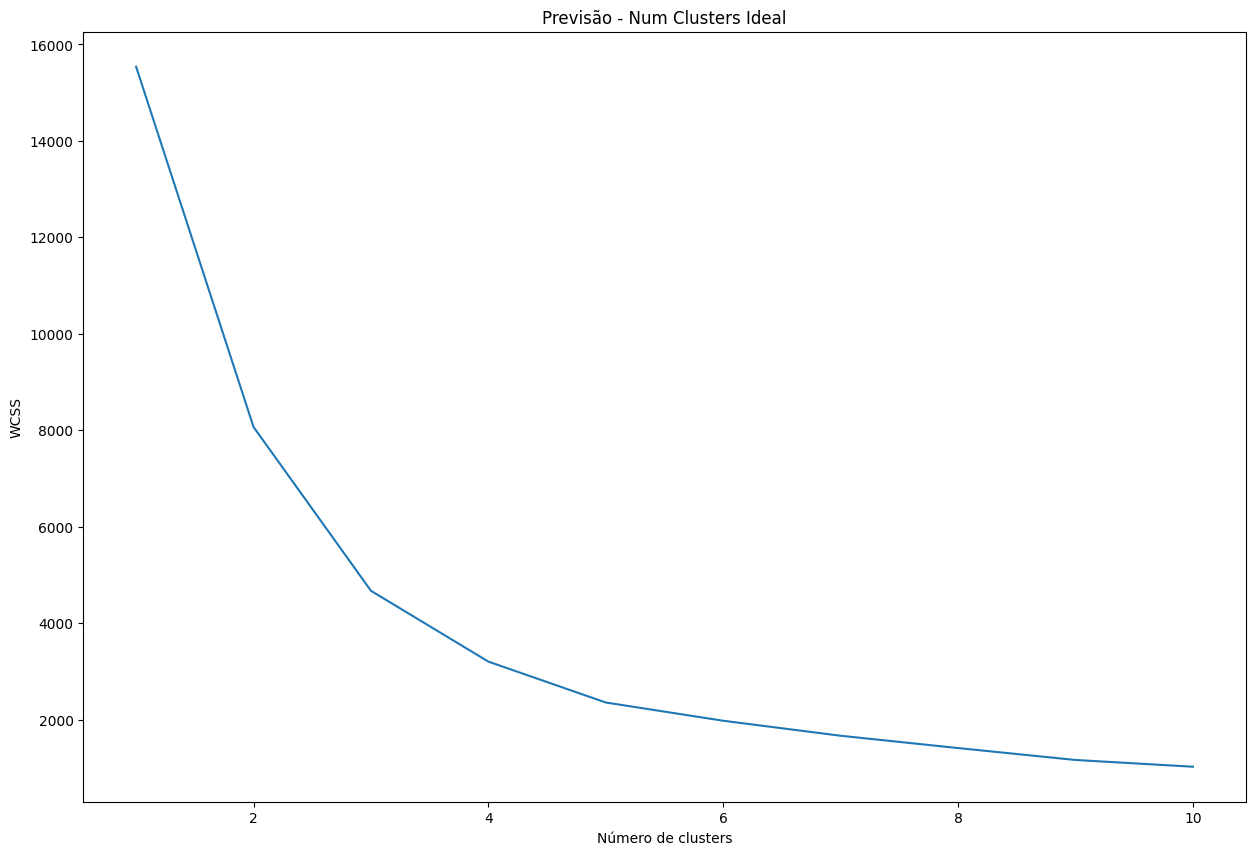

In [ ]:
wcss=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init ='k-means++', max_iter=300, n_init=10,random_state=0 )
    kmeans.fit(reduced)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(15, 10))

plt.plot(range(1,11),wcss)
plt.title('Previsão - Num Clusters Ideal')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
from math import sqrt
def numero_otimo_clusters(wcss):
    x1, y1 = 1, wcss[0]
    x2, y2 = 10, wcss[len(wcss)-1]

    distances = []
    for i in range(len(wcss)):
        x0 = i+2
        y0 = wcss[i]
        numerator = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1)
        denominator = sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distances.append(numerator/denominator)

    return distances.index(max(distances)) + 2

In [ ]:
k_opt = numero_otimo_clusters(wcss)
print(k_opt)

4


In [ ]:
## Specify the number of clusters
kmeans = KMeans(n_clusters=k_opt, init='k-means++', max_iter=600, random_state=42)

## Fit the input data
kmeans = kmeans.fit(reduced)

## Get the cluster labels
labels = kmeans.predict(reduced)

## Centroid values
centroid = kmeans.cluster_centers_

## Cluster values
clusters = kmeans.labels_.tolist()

In [ ]:
names_fw = list(yng_plyr['Player'])

reduced['cluster'] = clusters


for column in list(yng_plyr.columns):
    reduced[column] = list(yng_plyr[column])

reduced

,0,1,cluster,Player,Nation,Pos,Club,Age_y,MP,Playing Time Starts,...,Playing Time MP,Expected xG,Expected npxG+xAG,Progression PrgC,Progression PrgP,Progression PrgR,Performance Recov,Aerial Duels Won,Aerial Duels Lost,Aerial Duels Won%
0,17.565580,1.897744,1,Erling Haaland,no NOR,FW,Manchester City,23,13.0,13.0,...,0.0,13.4,12.9,11.0,9.0,49.0,17.0,18.0,17.0,51.4
1,0.696473,1.541217,2,Malte Zumdieck,de GER,FW,Meppen U19,18,11.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.241444,2.358969,2,Lasse Zumdieck,de GER,FW,Meppen U19,18,11.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.468201,0.340408,0,Michael Klaß,de GER,FW,Meppen U19,17,8.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.292124,-0.567541,0,Dzejlan Fejzić,de GER,FW,Meppen U19,18,8.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,-1.892233,-1.070781,0,Gabriel Estasio,ve VEN,FW,Universidad Central de Venezuela FC,18,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
888,0.609886,1.687981,2,Quentin Gandlau,de GER,FW,Dresden U17,16,0.0,10.0,...,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
889,0.544078,1.746725,2,Daniel Blessing,de GER,FW,Dresden U17,16,0.0,10.0,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
890,0.879632,2.409048,2,Marc Fischer,de GER,FW,Dresden U17,16,0.0,9.0,...,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
reduced = reduced.rename(columns = {0:'X',1:'Y'})

In [ ]:
distance_matrix = pd.DataFrame(index=reduced['Player'], columns=reduced['Player'])
distance_matrix.head()

Player,Erling Haaland,Malte Zumdieck,Lasse Zumdieck,Michael Klaß,Dzejlan Fejzić,Lyle Foster,Pietro Pellegri,Marley Aké,Badredine Bouanani,Jovan Mijatović,...,Amadou Diallo,Nassim Azaouzi,Renzo Machado,Valentin Carboni,Fabricio Baruja,Gabriel Estasio,Quentin Gandlau,Daniel Blessing,Marc Fischer,Carl Möller
Player,,,,,,,,,,,,,,,,,,,,,
Erling Haaland,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Malte Zumdieck,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lasse Zumdieck,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Michael Klaß,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dzejlan Fejzić,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for i in range(len(distance_matrix)):
  x_i = reduced.iloc[i, 0]
  y_i = reduced.iloc[i, 1]
  for j in range(len(distance_matrix)):
    x_j = reduced.iloc[j, 0]
    y_j = reduced.iloc[j, 1]
    distance_matrix.iloc[i, j] = np.sqrt((x_i - x_j) ** 2 + (y_i - y_j) ** 2)

In [ ]:
distance_matrix

Player,Erling Haaland,Malte Zumdieck,Lasse Zumdieck,Michael Klaß,Dzejlan Fejzić,Lyle Foster,Pietro Pellegri,Marley Aké,Badredine Bouanani,Jovan Mijatović,...,Amadou Diallo,Nassim Azaouzi,Renzo Machado,Valentin Carboni,Fabricio Baruja,Gabriel Estasio,Quentin Gandlau,Daniel Blessing,Marc Fischer,Carl Möller
Player,,,,,,,,,,,,,,,,,,,,,
Erling Haaland,0.0,16.872874,16.33065,18.100899,19.018166,18.309531,19.682952,18.070494,17.827707,17.390368,...,19.188046,19.675316,18.213463,17.381899,19.764472,19.682952,16.956991,17.022172,16.693779,18.900141
Malte Zumdieck,16.872874,0.0,0.982707,1.672844,2.898513,3.677369,3.67749,2.899868,3.313154,1.41275,...,3.083566,3.615572,1.530091,2.040123,3.666967,3.67749,0.170403,0.255847,0.886949,2.38156
Lasse Zumdieck,16.33065,0.982707,0.0,2.645274,3.870843,4.623907,4.645763,3.857784,4.23274,1.155821,...,4.053964,4.580821,2.455815,2.966015,4.628276,4.645763,0.921461,0.927989,0.365261,3.315991
Michael Klaß,18.100899,1.672844,2.645274,0.0,1.226059,2.335815,2.004824,1.562085,2.139043,2.611725,...,1.410723,1.944174,0.431361,1.14735,1.998434,2.004824,1.725754,1.732754,2.468993,0.804554
Dzejlan Fejzić,19.018166,2.898513,3.870843,1.226059,0.0,1.720316,0.783186,1.232739,1.813551,3.743349,...,0.189485,0.731401,1.480525,1.640611,0.798898,0.783186,2.950428,2.954228,3.684645,0.746113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Gabriel Estasio,19.682952,3.67749,4.645763,2.004824,0.783186,1.816428,0.0,1.66097,2.103404,4.458013,...,0.595122,0.0948,2.223858,2.317364,0.155223,0.0,3.724429,3.724775,4.44887,1.401192
Quentin Gandlau,16.956991,0.170403,0.921461,1.725754,2.950428,3.796289,3.724429,3.013736,3.444026,1.245321,...,3.133014,3.659361,1.541673,2.172617,3.707011,3.724429,0.0,0.088213,0.76987,2.400616
Daniel Blessing,17.022172,0.255847,0.927989,1.732754,2.954228,3.83779,3.724775,3.052669,3.493343,1.169057,...,3.13527,3.658078,1.527842,2.224096,3.703701,3.724775,0.088213,0.0,0.742475,2.388007


In [ ]:
similarity_matrix = pd.DataFrame(index=reduced['Player'], columns=reduced['Player'])
max_euc_distance = distance_matrix.max(axis=1)
for i in range(len(distance_matrix)):
  for j in range(len(distance_matrix)):
    similarity_matrix.iloc[i, j] = ((max_euc_distance[i]-distance_matrix.iloc[i, j])*100/max_euc_distance[i])

In [ ]:
similarity_matrix

Player,Erling Haaland,Malte Zumdieck,Lasse Zumdieck,Michael Klaß,Dzejlan Fejzić,Lyle Foster,Pietro Pellegri,Marley Aké,Badredine Bouanani,Jovan Mijatović,...,Amadou Diallo,Nassim Azaouzi,Renzo Machado,Valentin Carboni,Fabricio Baruja,Gabriel Estasio,Quentin Gandlau,Daniel Blessing,Marc Fischer,Carl Möller
Player,,,,,,,,,,,,,,,,,,,,,
Erling Haaland,100.0,37.715061,39.716639,33.181901,29.795878,32.41175,27.34187,33.294138,34.190368,35.80477,...,29.168779,27.370059,32.766378,35.836035,27.040947,27.34187,37.40455,37.16394,38.376176,30.231558
Malte Zumdieck,42.629196,100.0,96.65862,94.31203,90.144535,87.496286,87.495875,90.139926,88.734681,95.196395,...,89.51532,87.706405,94.797415,93.063215,87.531652,87.495875,99.420601,99.130074,96.984215,91.902267
Lasse Zumdieck,44.167933,96.640272,100.0,90.956201,86.766161,84.191551,84.116826,86.810808,85.52889,96.048421,...,86.140101,84.338853,91.603934,89.859636,84.176611,84.116826,96.849663,96.827345,98.751228,88.663118
Michael Klaß,39.753831,94.432186,91.195596,100.0,95.919243,92.225584,93.327238,94.80083,92.880511,91.307258,...,95.304617,93.529104,98.564278,96.181214,93.348508,93.327238,94.256083,94.232785,91.782322,97.322162
Dzejlan Fejzić,37.692306,90.503834,87.318266,95.983161,100.0,94.363866,97.434109,95.961276,94.058408,87.735965,...,99.379206,97.603769,95.149475,94.624996,97.382635,97.434109,90.333749,90.321299,87.928293,97.555569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Gabriel Estasio,36.389553,88.115261,84.986039,93.520902,97.468935,94.129753,100.0,94.632156,93.202317,85.5928,...,98.076713,99.693631,92.813038,92.510849,99.498358,100.0,87.963565,87.962446,85.622349,95.471692
Quentin Gandlau,42.612066,99.423303,96.881479,94.159492,90.014799,87.152132,87.39533,89.800543,88.344303,95.785431,...,89.396868,87.615542,94.78248,92.647162,87.454276,87.39533,100.0,99.701458,97.394511,91.875539
Daniel Blessing,42.554388,99.136579,96.868269,94.152386,90.030212,87.048411,87.429808,89.697998,88.210831,96.054723,...,89.419242,87.654893,94.843911,92.494225,87.500927,87.429808,99.702303,100.0,97.494332,91.941067


In [ ]:


index_player = {name: index for index, name in enumerate(yng_plyr['Player'])}


player_name = 'Dušan Vlahović'
index = index_player[player_name]

scaler = StandardScaler()

data_players = yng_plyr.select_dtypes(include=['int', 'float64'])

data_players_normalized = scaler.fit_transform(data_players)

player_data = data_players.iloc[index].values.reshape(1, -1)
player_data_normalized = scaler.transform(player_data)
similarities = cosine_similarity(player_data_normalized, data_players_normalized)
similarities_converted = ((similarities + 1) / 2 * 100).round(1)

result_df = pd.DataFrame({
        'Player': yng_plyr['Player'],
        'Squad': yng_plyr['Club'],
        '% similarity': similarities_converted[0]
    })


In [ ]:
result_df.sort_values(by='% similarity', ascending=False).to_csv('/content/drive/MyDrive/similarity2.csv')

In [ ]:
result_df

,Player,Squad,% similarity
0,Erling Haaland,Manchester City,100.0
161,Vitor Roque,Athletico Paranaense,88.6
26,Eli Junior Kroupi,Lorient,85.2
300,Endrick,Palmeiras,84.4
677,Deivid Washington,Santos,84.3
120,George Ilenikhena,Antwerp,83.5
70,Francesco Esposito,Spezia,83.3
664,Facinet Conte,Bastia,82.0
104,Kevin Denkey,Nimes,81.8
562,Jean Mattéo Bahoya,Angers,81.6
